In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2_contingency
from scipy.stats import fisher_exact
import os
print(os.getcwd())
df = pd.read_csv("hospital-data.csv")
df.head()

C:\Users\turbo\MGT 151R\MGT151R-DA-Project


,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
0,1,5955,0,11542,-552,10848.0,1668,10368,-236220,627780,...,0,120,0.0,100,70,0,10,0,0,0
1,2,2487,0,15741,-1039,14921.0,1721,14621,-221160,1506840,...,0,150,0.0,0,100,0,20,0,0,0
2,3,2861,0,4394,-590,4210.0,1090,3010,-218640,40560,...,0,0,0.0,0,50,0,0,0,0,0
3,4,1903,0,20990,-778,20222.0,2522,17822,-201120,576480,...,0,80,0.0,100,100,0,50,0,0,0
4,5,4416,0,21531,-1009,22391.0,2591,20291,-67560,3734040,...,0,0,0.0,0,160,0,10,900,0,2100


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6388 entries, 0 to 6387
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   caseid               6388 non-null   int64  
 1   subjectid            6388 non-null   int64  
 2   casestart            6388 non-null   int64  
 3   caseend              6388 non-null   int64  
 4   anestart             6388 non-null   int64  
 5   aneend               6388 non-null   float64
 6   opstart              6388 non-null   int64  
 7   opend                6388 non-null   int64  
 8   adm                  6388 non-null   int64  
 9   dis                  6388 non-null   int64  
 10  icu_days             6388 non-null   int64  
 11  death_inhosp         6388 non-null   int64  
 12  age                  6388 non-null   float64
 13  sex                  6388 non-null   object 
 14  height               6388 non-null   float64
 15  weight               6388 non-null   f

In [18]:
df.describe()

,caseid,subjectid,casestart,caseend,anestart,aneend,opstart,opend,adm,dis,...,intraop_colloid,intraop_ppf,intraop_mdz,intraop_ftn,intraop_rocu,intraop_vecu,intraop_eph,intraop_phe,intraop_epi,intraop_ca
count,6388.000000,6388.000000,6388.0,6388.000000,6388.000000,6.388000e+03,6388.000000,6388.000000,6.388000e+03,6.388000e+03,...,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000,6388.000000
mean,3194.500000,3047.726362,0.0,11348.680651,-757.002974,-5.666559e+05,2188.399029,10347.526769,-8.543255e+05,5.050752e+04,...,32.113807,39.776769,0.036944,17.043676,72.824828,0.016907,7.753601,32.631027,7.894646,120.781935
std,1844.201092,1757.857225,0.0,6658.506842,783.520044,4.618684e+07,995.381670,6602.562588,4.610906e+07,4.613061e+07,...,137.512127,54.534878,0.364006,38.029277,36.141193,0.444540,13.218972,160.513431,469.413023,535.113499
min,1.000000,1.000000,0.0,1640.000000,-19065.000000,-3.691470e+09,0.000000,786.000000,-3.685366e+09,-3.685366e+09,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1597.750000,1532.750000,0.0,6194.500000,-1090.250000,6.013750e+03,1440.000000,5253.750000,-2.250750e+05,2.086800e+05,...,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3194.500000,3053.500000,0.0,9924.500000,-583.000000,9.769500e+03,2055.000000,8877.000000,-2.010600e+05,3.932400e+05,...,0.000000,0.000000,0.000000,0.000000,70.000000,0.000000,5.000000,0.000000,0.000000,0.000000
75%,4791.250000,4569.250000,0.0,15072.750000,-277.000000,1.492950e+04,2779.000000,14014.000000,-1.293000e+05,6.496500e+05,...,0.000000,100.000000,0.000000,0.000000,90.000000,0.000000,10.000000,0.000000,0.000000,0.000000
max,6388.000000,6090.000000,0.0,62494.000000,1984.000000,1.107090e+05,13461.000000,60697.000000,-7.200000e+02,1.930788e+07,...,1900.000000,200.000000,8.000000,200.000000,330.000000,20.000000,300.000000,4100.000000,37220.000000,15900.000000


In [19]:
df.columns


Index(['caseid', 'subjectid', 'casestart', 'caseend', 'anestart', 'aneend',
       'opstart', 'opend', 'adm', 'dis', 'icu_days', 'death_inhosp', 'age',
       'sex', 'height', 'weight', 'bmi', 'asa', 'emop', 'department', 'optype',
       'dx', 'opname', 'approach', 'position', 'ane_type', 'preop_htn',
       'preop_dm', 'preop_ecg', 'preop_pft', 'preop_hb', 'preop_plt',
       'preop_pt', 'preop_aptt', 'preop_na', 'preop_k', 'preop_gluc',
       'preop_alb', 'preop_ast', 'preop_alt', 'preop_bun', 'preop_cr',
       'preop_ph', 'preop_hco3', 'preop_be', 'preop_pao2', 'preop_paco2',
       'preop_sao2', 'cormack', 'airway', 'tubesize', 'dltubesize', 'lmasize',
       'iv1', 'iv2', 'aline1', 'aline2', 'cline1', 'cline2', 'intraop_ebl',
       'intraop_uo', 'intraop_rbc', 'intraop_ffp', 'intraop_crystalloid',
       'intraop_colloid', 'intraop_ppf', 'intraop_mdz', 'intraop_ftn',
       'intraop_rocu', 'intraop_vecu', 'intraop_eph', 'intraop_phe',
       'intraop_epi', 'intraop_ca'],
     

In [20]:
df.rename(columns={
    # Patient info
    'caseid':'Case_ID',
    'subjectid':'Patient_ID',
    'age':'Age',
    'sex':'Sex',
    'height':'Height_cm',
    'weight':'Weight_kg',
    'bmi':'BMI',
    
    # Outcome / post-op
    'death_inhosp':'Outcome',   # 0 = survived, 1 = died
    'icu_days':'ICU_Days',
    
    # Pre-op metrics
    'asa':'ASA_Score',
    'preop_htn':'Preop_Hypertension',
    'preop_dm':'Preop_Diabetes',
    'preop_ecg':'Preop_ECG_Abnormal',
    'preop_pft':'Preop_PFT_Abnormal',
    'preop_hb':'Preop_Hemoglobin',
    'preop_plt':'Preop_Platelets',
    'preop_pt':'Preop_PT',
    'preop_aptt':'Preop_aPTT',
    'preop_na':'Preop_Sodium',
    'preop_k':'Preop_Potassium',
    'preop_gluc':'Preop_Glucose',
    'preop_alb':'Preop_Albumin',
    'preop_ast':'Preop_AST',
    'preop_alt':'Preop_ALT',
    'preop_bun':'Preop_BUN',
    'preop_cr':'Preop_Creatinine',
    'preop_ph':'Preop_pH',
    'preop_hco3':'Preop_HCO3',
    'preop_be':'Preop_BaseExcess',
    'preop_pao2':'Preop_PaO2',
    'preop_paco2':'Preop_PaCO2',
    'preop_sao2':'Preop_SaO2',
    
    # Surgery info
    'department':'Department',
    'optype':'Surgery_Type',
    'dx':'Diagnosis',
    'opname':'Surgery_Name',
    'approach':'Surgery_Method',
    'position':'Patient_Position',
    'ane_type':'Anesthesia_Type',
    
    # Airway / lines
    'cormack':'Cormack_Grade',
    'airway':'Airway_Type',
    'tubesize':'ET_Tube_Size',
    'dltubesize':'DL_Tube_Size',
    'lmasize':'LMA_Size',
    'iv1':'IV1',
    'iv2':'IV2',
    'aline1':'Arterial_Line1',
    'aline2':'Arterial_Line2',
    'cline1':'Central_Line1',
    'cline2':'Central_Line2',
    
    # Intra-op measurements
    'intraop_ebl':'Intraop_EBL',
    'intraop_uo':'Intraop_UO',
    'intraop_rbc':'Intraop_RBC',
    'intraop_ffp':'Intraop_FFP',
    'intraop_crystalloid':'Intraop_Crystalloid',
    'intraop_colloid':'Intraop_Colloid',
    'intraop_ppf':'Intraop_PPF',
    'intraop_mdz':'Intraop_Midazolam',
    'intraop_ftn':'Intraop_Fentanyl',
    'intraop_rocu':'Intraop_Rocuronium',
    'intraop_vecu':'Intraop_Vecuronium',
    'intraop_eph':'Intraop_Ephedrine',
    'intraop_phe':'Intraop_Phenylephrine',
    'intraop_epi':'Intraop_Epinephrine',
    'intraop_ca':'Intraop_Calcium'
}, inplace=True)

In [21]:
df.columns

Index(['Case_ID', 'Patient_ID', 'casestart', 'caseend', 'anestart', 'aneend',
       'opstart', 'opend', 'adm', 'dis', 'ICU_Days', 'Outcome', 'Age', 'Sex',
       'Height_cm', 'Weight_kg', 'BMI', 'ASA_Score', 'emop', 'Department',
       'Surgery_Type', 'Diagnosis', 'Surgery_Name', 'Surgery_Method',
       'Patient_Position', 'Anesthesia_Type', 'Preop_Hypertension',
       'Preop_Diabetes', 'Preop_ECG_Abnormal', 'Preop_PFT_Abnormal',
       'Preop_Hemoglobin', 'Preop_Platelets', 'Preop_PT', 'Preop_aPTT',
       'Preop_Sodium', 'Preop_Potassium', 'Preop_Glucose', 'Preop_Albumin',
       'Preop_AST', 'Preop_ALT', 'Preop_BUN', 'Preop_Creatinine', 'Preop_pH',
       'Preop_HCO3', 'Preop_BaseExcess', 'Preop_PaO2', 'Preop_PaCO2',
       'Preop_SaO2', 'Cormack_Grade', 'Airway_Type', 'ET_Tube_Size',
       'DL_Tube_Size', 'LMA_Size', 'IV1', 'IV2', 'Arterial_Line1',
       'Arterial_Line2', 'Central_Line1', 'Central_Line2', 'Intraop_EBL',
       'Intraop_UO', 'Intraop_RBC', 'Intraop_FFP', 'Intr

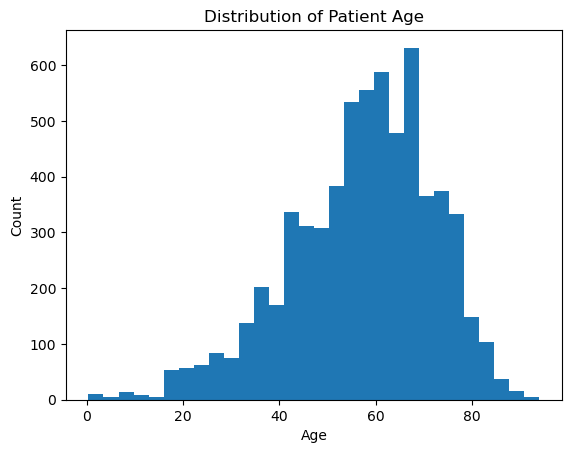

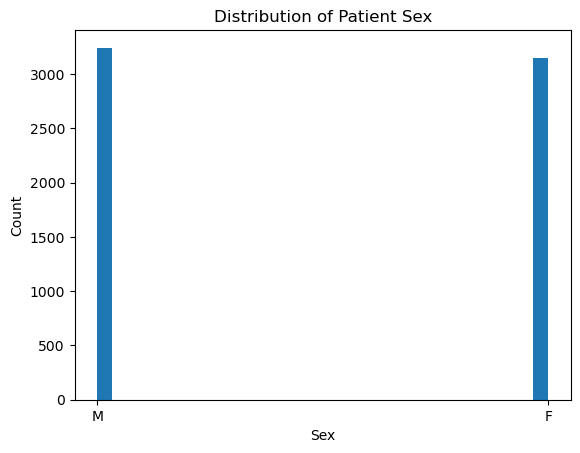

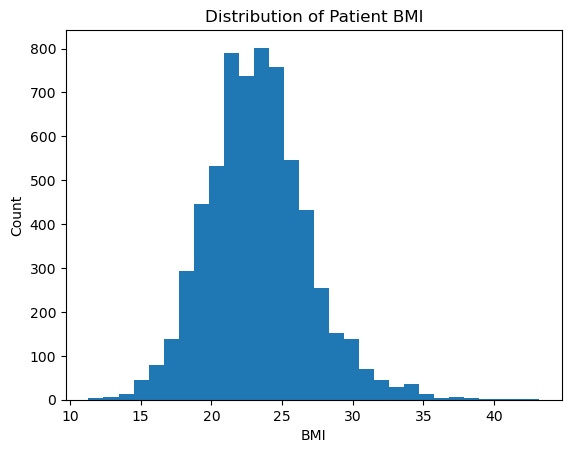

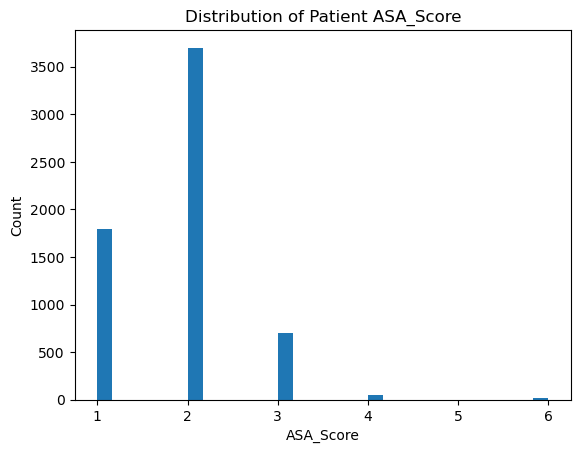

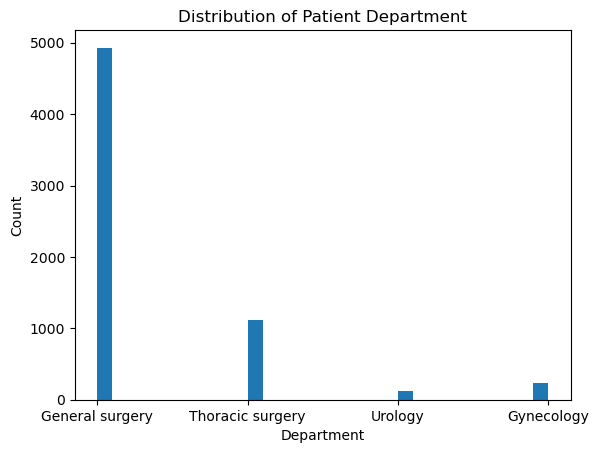

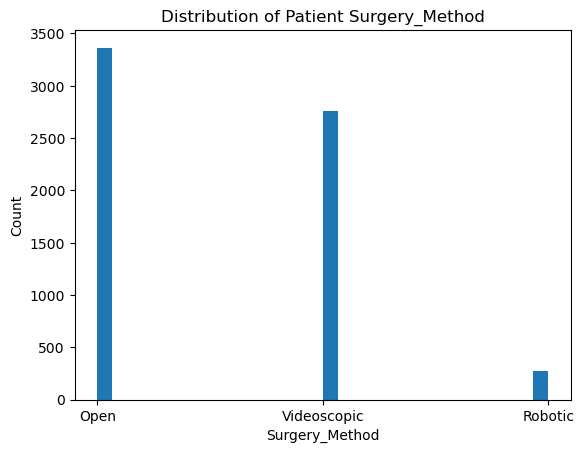

In [22]:
cols = ['Age', 'Sex', 'BMI', 'ASA_Score', 'Department', 'Surgery_Method']

for col in cols:
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of Patient {col}")
    plt.show()

In [23]:
correlation = df['BMI'].corr(df['Outcome'])
print(f"Correlation between BMI and Surgery Outcome: {correlation:.3f}")

Correlation between BMI and Surgery Outcome: -0.003


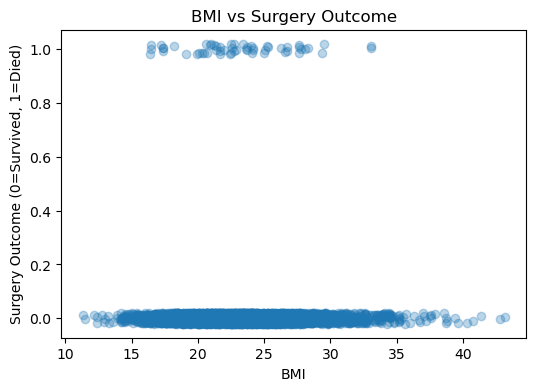

In [24]:
plt.figure(figsize=(6,4))
plt.scatter(df['BMI'], df['Outcome'] + np.random.uniform(-0.02, 0.02, size=len(df)), alpha=0.3)
plt.xlabel('BMI')
plt.ylabel('Surgery Outcome (0=Survived, 1=Died)')
plt.title('BMI vs Surgery Outcome')
plt.show()

C:\Users\turbo\AppData\Local\Temp\ipykernel_4172\3631955836.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mortality_by_bmi = df.groupby('BMI_group')['Outcome'].mean()


BMI_group
Underweight    0.015238
Normal         0.007874
Overweight     0.009696
Obese          0.007937
Name: Outcome, dtype: float64


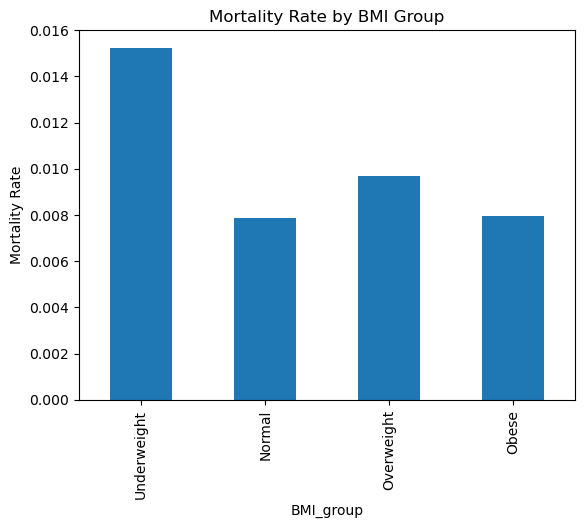

In [25]:
bins = [0, 18.5, 25, 30, 100]  
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df['BMI_group'] = pd.cut(df['BMI'], bins=bins, labels=labels)
mortality_by_bmi = df.groupby('BMI_group')['Outcome'].mean()
print(mortality_by_bmi)

mortality_by_bmi.plot(kind='bar')
plt.ylabel('Mortality Rate')
plt.title('Mortality Rate by BMI Group')
plt.savefig("bmi_vs_mortality.png", dpi=300, bbox_inches='tight')
plt.show()

In [26]:
contingency_table = pd.crosstab(df['BMI_group'], df['Outcome'])
print(contingency_table)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic = {chi2:.3f}, p-value = {p:.3f}")

Outcome         0   1
BMI_group            
Underweight   517   8
Normal       4032  32
Overweight   1532  15
Obese         250   2
Chi-square statistic = 3.006, p-value = 0.391


BMI_Group
Underweight    1.481905
Normal         0.511565
Overweight     0.372980
Obese          0.384921
Name: ICU_Days, dtype: float64


C:\Users\turbo\AppData\Local\Temp\ipykernel_4172\4108277317.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  icu_by_bmi_group = df.groupby('BMI_Group')['ICU_Days'].mean()


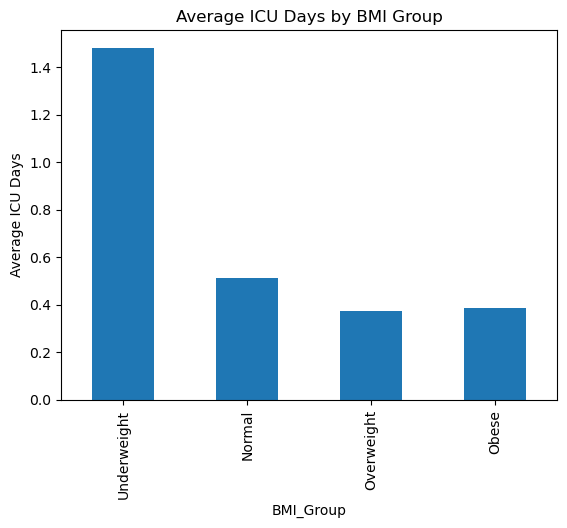

In [27]:
bins = [0, 18.5, 25, 30, 100]
labels = ['Underweight', 'Normal', 'Overweight', 'Obese']

df['BMI_Group'] = pd.cut(df['BMI'], bins=bins, labels=labels)

icu_by_bmi_group = df.groupby('BMI_Group')['ICU_Days'].mean()
print(icu_by_bmi_group)

icu_by_bmi_group.plot(kind='bar')
plt.ylabel('Average ICU Days')
plt.title('Average ICU Days by BMI Group')
plt.savefig("bmi_vs_icu.png", dpi=300, bbox_inches='tight')
plt.show()

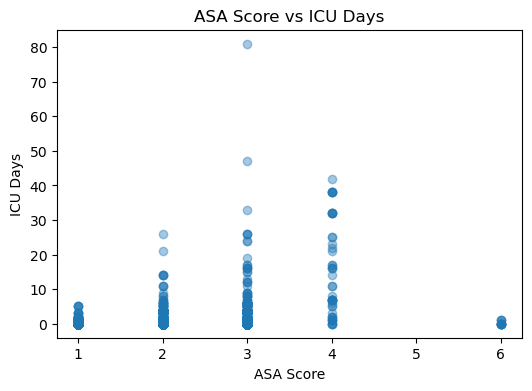

In [67]:
df_no_outlier = df[df['ICU_Days'] != 179].copy()
clean = df_no_outlier[['ASA_Score', 'ICU_Days']].dropna()
x = clean['ASA_Score'].astype(float).values
y = clean['ICU_Days'].astype(float).values
plt.figure(figsize=(6,4))
plt.scatter(x, y, alpha=0.4)
plt.xlabel('ASA Score')
plt.ylabel('ICU Days')
plt.title('ASA Score vs ICU Days')
plt.savefig("asa_vs_icu_no_outlier.png", dpi=300, bbox_inches='tight')
plt.show()

ASA_Score
1.0    0.005022
2.0    0.004596
3.0    0.024182
4.0    0.250000
6.0    0.000000
Name: Outcome, dtype: float64


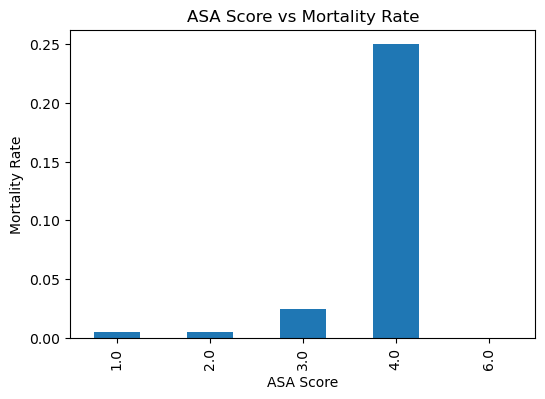

In [59]:
mortality_by_asa = df.groupby('ASA_Score')['Outcome'].mean()
print(mortality_by_asa)
plt.figure(figsize=(6,4))
mortality_by_asa.plot(kind='bar')
plt.ylabel('Mortality Rate')
plt.xlabel('ASA Score')
plt.title('ASA Score vs Mortality Rate')
plt.savefig("asa_vs_mortality.png", dpi=300, bbox_inches='tight')
plt.show()

In [65]:
from scipy.stats import pearsonr

# Drop rows where either ASA or ICU is missing
clean = df[['ASA_Score', 'ICU_Days']].dropna()

asa = clean['ASA_Score']
icu = clean['ICU_Days']

# Run correlation test
r, p = pearsonr(asa, icu)

print("Correlation coefficient (r):", r)
print("p-value:", p)

Correlation coefficient (r): 0.2158594850448171
p-value: 7.563383313538405e-67


In [69]:
table = pd.crosstab(df['ASA_Score'], df['Outcome'])
print(table)

# Run chi-square test
chi2, p, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

Outcome       0   1
ASA_Score          
1.0        1783   9
2.0        3682  17
3.0         686  17
4.0          36  12
6.0          13   0
Chi-square statistic: 350.0384399643367
p-value: 1.72059488243708e-74
Degrees of freedom: 4


In [71]:
clean = df[['BMI', 'ICU_Days']].dropna()

bmi = clean['BMI']
icu = clean['ICU_Days']

r, p = pearsonr(bmi, icu)

print("Correlation coefficient (r):", r)
print("p-value:", p)

Correlation coefficient (r): -0.06382570623941444
p-value: 3.299648709122706e-07
